# Reconnaissance faciale en direct — un premier système de machine learning

**Objectif.** Construire, en une séance, un système qui reconnaît *votre* visage
dans le flux vidéo de la webcam, et qui affiche en direct un cadre coloré annoté.

Le point important : **au départ, le programme ne sait rien**. Il détecte bien un
visage, mais il est incapable de dire de qui il s'agit. C'est vous qui allez lui
montrer quelques dizaines d'exemples, et il saura ensuite répondre en temps réel.

**Le déroulé**

| Étape | Ce qu'on fait | L'idée |
|---|---|---|
| 1 | Ouvrir la caméra | — |
| 2 | Détecter les visages | *donné* (algorithme de 2001, pas d'apprentissage) |
| 3 | Transformer une image en vecteur | une image = un point de $\mathbb{R}^{1024}$ |
| 4 | Capturer des exemples étiquetés | constituer un **jeu de données** |
| 5 | Entraîner un classifieur | `scikit-learn`, une ligne |
| 6 | Prédire en direct | le résultat |
| 7 | Casser le modèle | comprendre le **sur-apprentissage** |

**Données personnelles.** Tout reste sur cette machine : aucune image n'est envoyée
nulle part. La dernière cellule du notebook efface les données capturées. Ne
capturez que des personnes qui sont d'accord.

---
## 0. Imports et vérifications

On travaille avec :

- **`numpy`** pour manipuler les images comme des tableaux de nombres,
- **`opencv` (`cv2`)** pour la caméra et la détection de visages,
- **`scikit-learn`** pour le classifieur.

In [26]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output

print("numpy  ", np.__version__)
print("opencv ", cv2.__version__)

# Le détecteur de visages est livré avec opencv : c'est un simple fichier XML.
CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
CASCADE = cv2.CascadeClassifier(CASCADE_PATH)
assert not CASCADE.empty(), "Le fichier du détecteur est introuvable."
print("détecteur chargé :", CASCADE_PATH.split("/")[-1])

numpy   2.2.6
opencv  4.12.0
détecteur chargé : haarcascade_frontalface_default.xml


In [50]:
# ---- Paramètres du TP (à ajuster si besoin) ----------------------------
CAMERA_INDEX = 0          # 0 = webcam intégrée
IMG_SIZE     = 64         # on redimensionne chaque visage en 32 x 32
CLASSES      = ["moi", "quelqu'un d'autre"]
COLORS       = [(0, 200, 0), (0, 0, 230)]   # BGR : vert, rouge

model = None              # pas encore de modèle : c'est tout l'enjeu

---
## 1. La caméra

Deux fonctions utilitaires : une pour ouvrir la caméra, une pour afficher une image
**dans le notebook**.

> ⚠️ On n'utilise **jamais** `cv2.imshow()` dans un notebook sur macOS : la fenêtre
> native se fige. On encode l'image en JPEG et on l'affiche dans la sortie de la
> cellule.

In [51]:
def open_camera(index=CAMERA_INDEX, warmup=8):
    """Ouvre la caméra et jette les premières images (le temps de l'auto-exposition)."""
    cap = cv2.VideoCapture(index)
    if not cap.isOpened():
        cap.release()
        raise RuntimeError(
            "Caméra inaccessible.\n"
            "  - macOS : Réglages Système > Confidentialité et sécurité > Caméra,\n"
            "    autorisez l'application qui lance Python (Terminal, VS Code...).\n"
            "  - Vérifiez qu'aucun autre programme (Zoom, Photo Booth) ne l'utilise.\n"
            "  - Si une cellule précédente a planté, la caméra est peut-être restée\n"
            "    verrouillée : redémarrez le noyau."
        )
    for _ in range(warmup):
        cap.read()
    return cap


def show_frame(frame, width=520):
    """Affiche une image BGR dans la sortie de la cellule."""
    ok, buf = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
    display(Image(data=buf.tobytes(), width=width))

Test : on prend **une seule** image. C'est cette cellule qui déclenchera la
demande d'autorisation macOS au premier lancement.

type : <class 'numpy.ndarray'> | forme : (1080, 1920, 3) | valeurs : uint8


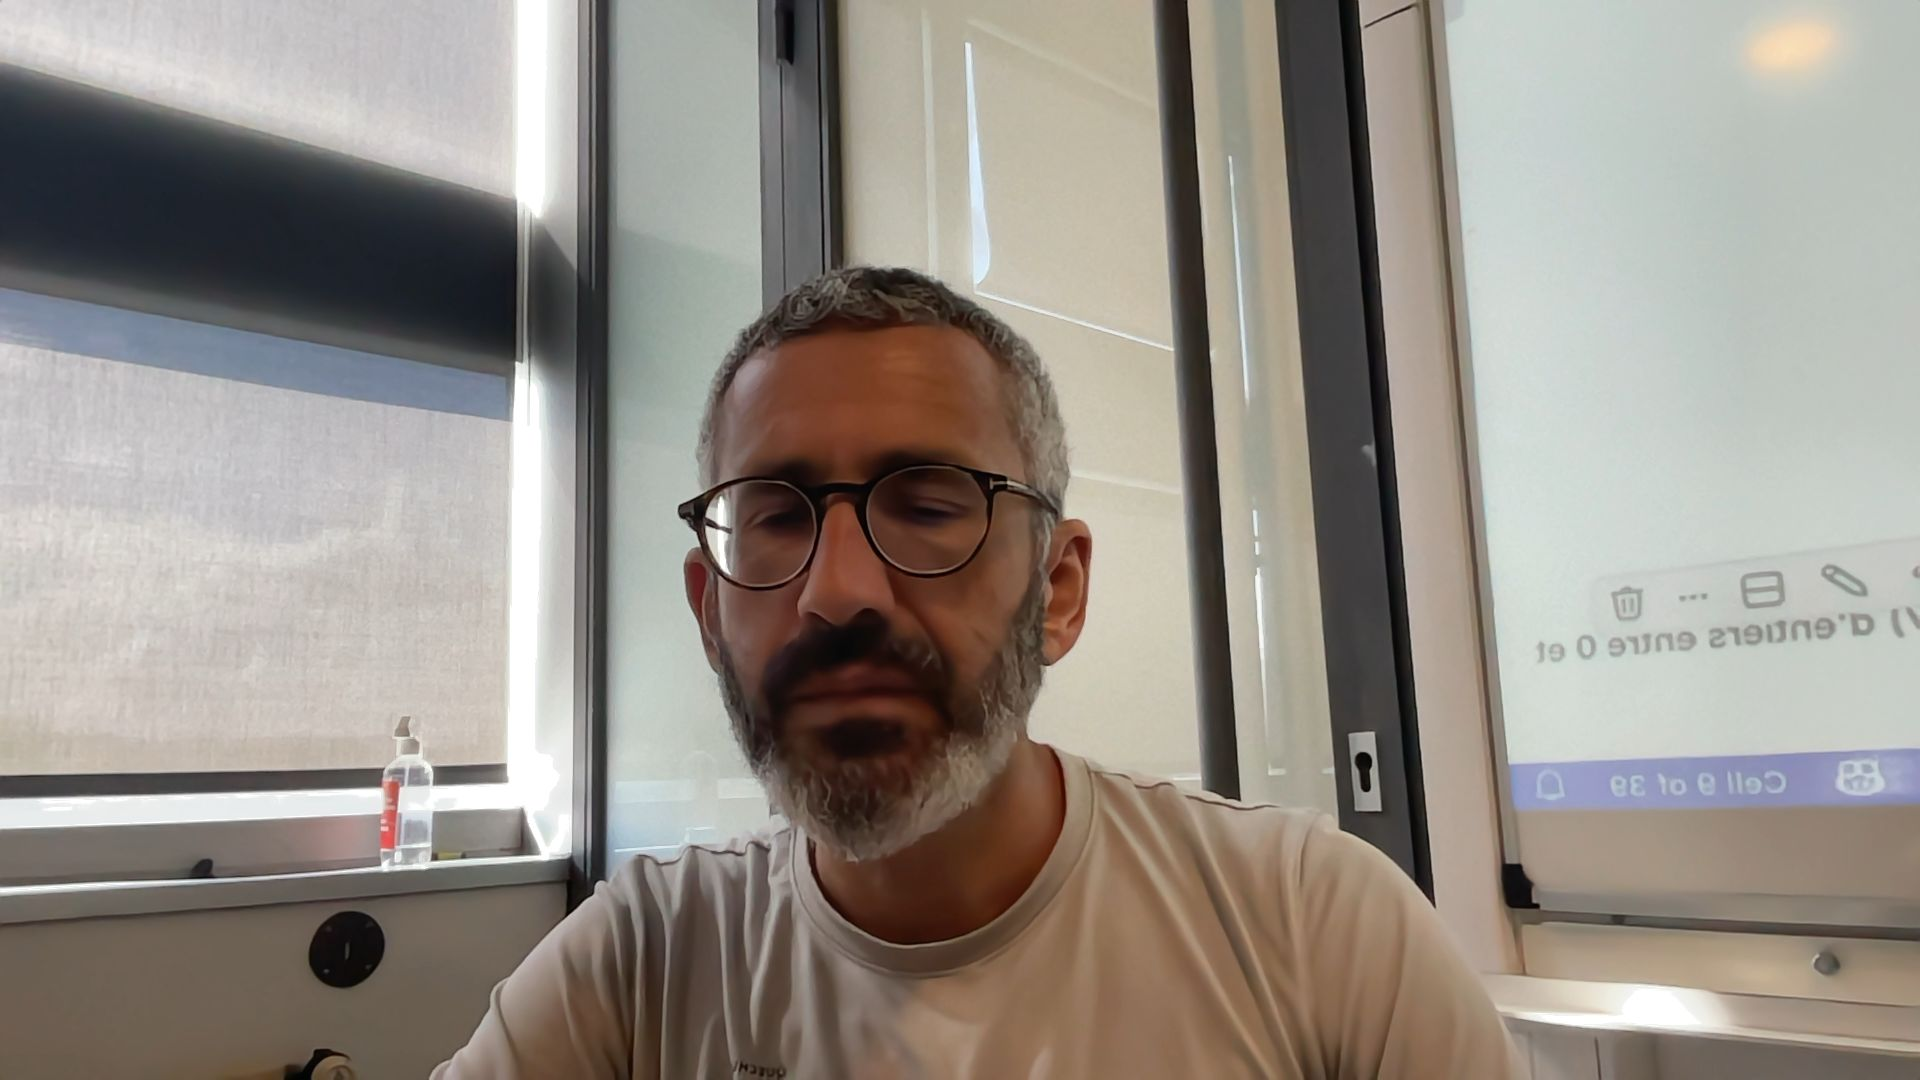

In [52]:
cap = open_camera()
try:
    ok, frame = cap.read()
finally:
    cap.release()          # ⚠️ TOUJOURS libérer la caméra, sinon elle reste bloquée

frame = cv2.flip(frame, 1)             # effet miroir, plus naturel
print("type :", type(frame), "| forme :", frame.shape, "| valeurs :", frame.dtype)
show_frame(frame)

Une image couleur est donc un tableau numpy de forme `(hauteur, largeur, 3)` :
trois canaux (bleu, vert, rouge chez OpenCV) d'entiers entre 0 et 255.

---
## 2. Détecter un visage — ce qui vous est *donné*

La détection utilise les **cascades de Haar** (Viola & Jones, 2001). Ce n'est pas
de l'apprentissage : c'est un algorithme figé, livré avec OpenCV, qui répond à la
question *« y a-t-il un visage, et où ? »* — mais **pas** *« de qui est-ce le
visage ? »*.

C'est précisément la partie que vous allez ajouter.

In [53]:
def detect_faces(frame, scale=1.2, neighbors=6, min_size=(80, 80)):
    """Renvoie un tableau de boîtes (x, y, largeur, hauteur), une par visage."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)          # égalise le contraste : aide beaucoup
    return CASCADE.detectMultiScale(gray, scale, neighbors, minSize=min_size)


def draw_box(frame, box, text, color):
    x, y, w, h = box
    cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
    cv2.rectangle(frame, (x, y - 22), (x + w, y), color, -1)
    cv2.putText(frame, text, (x + 4, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

In [54]:
def live(annotate=None, seconds=15, width=520, banner=""):
    """Boucle vidéo : lit la caméra, applique `annotate(frame)`, affiche."""
    cap = open_camera()
    last = None
    try:
        t0 = time.time()
        while (dt := time.time() - t0) < seconds:
            ok, frame = cap.read()
            if not ok:
                continue
            frame = cv2.flip(frame, 1)
            if annotate is not None:
                annotate(frame)
            last = frame
            clear_output(wait=True)
            show_frame(frame, width)
            print(f"{banner}    {seconds - dt:4.0f} s restantes    (bouton ■ pour arrêter)")
    except KeyboardInterrupt:
        print("Interrompu.")
    finally:
        cap.release()
    return last

Lançons la détection **avant** tout apprentissage. Le visage est bien trouvé,
mais le système n'a rien à en dire : le cadre est gris.

In [55]:
def annotate_detection_only(frame):
    for box in detect_faces(frame):
        draw_box(frame, box, "modele non entraine", (128, 128, 128))

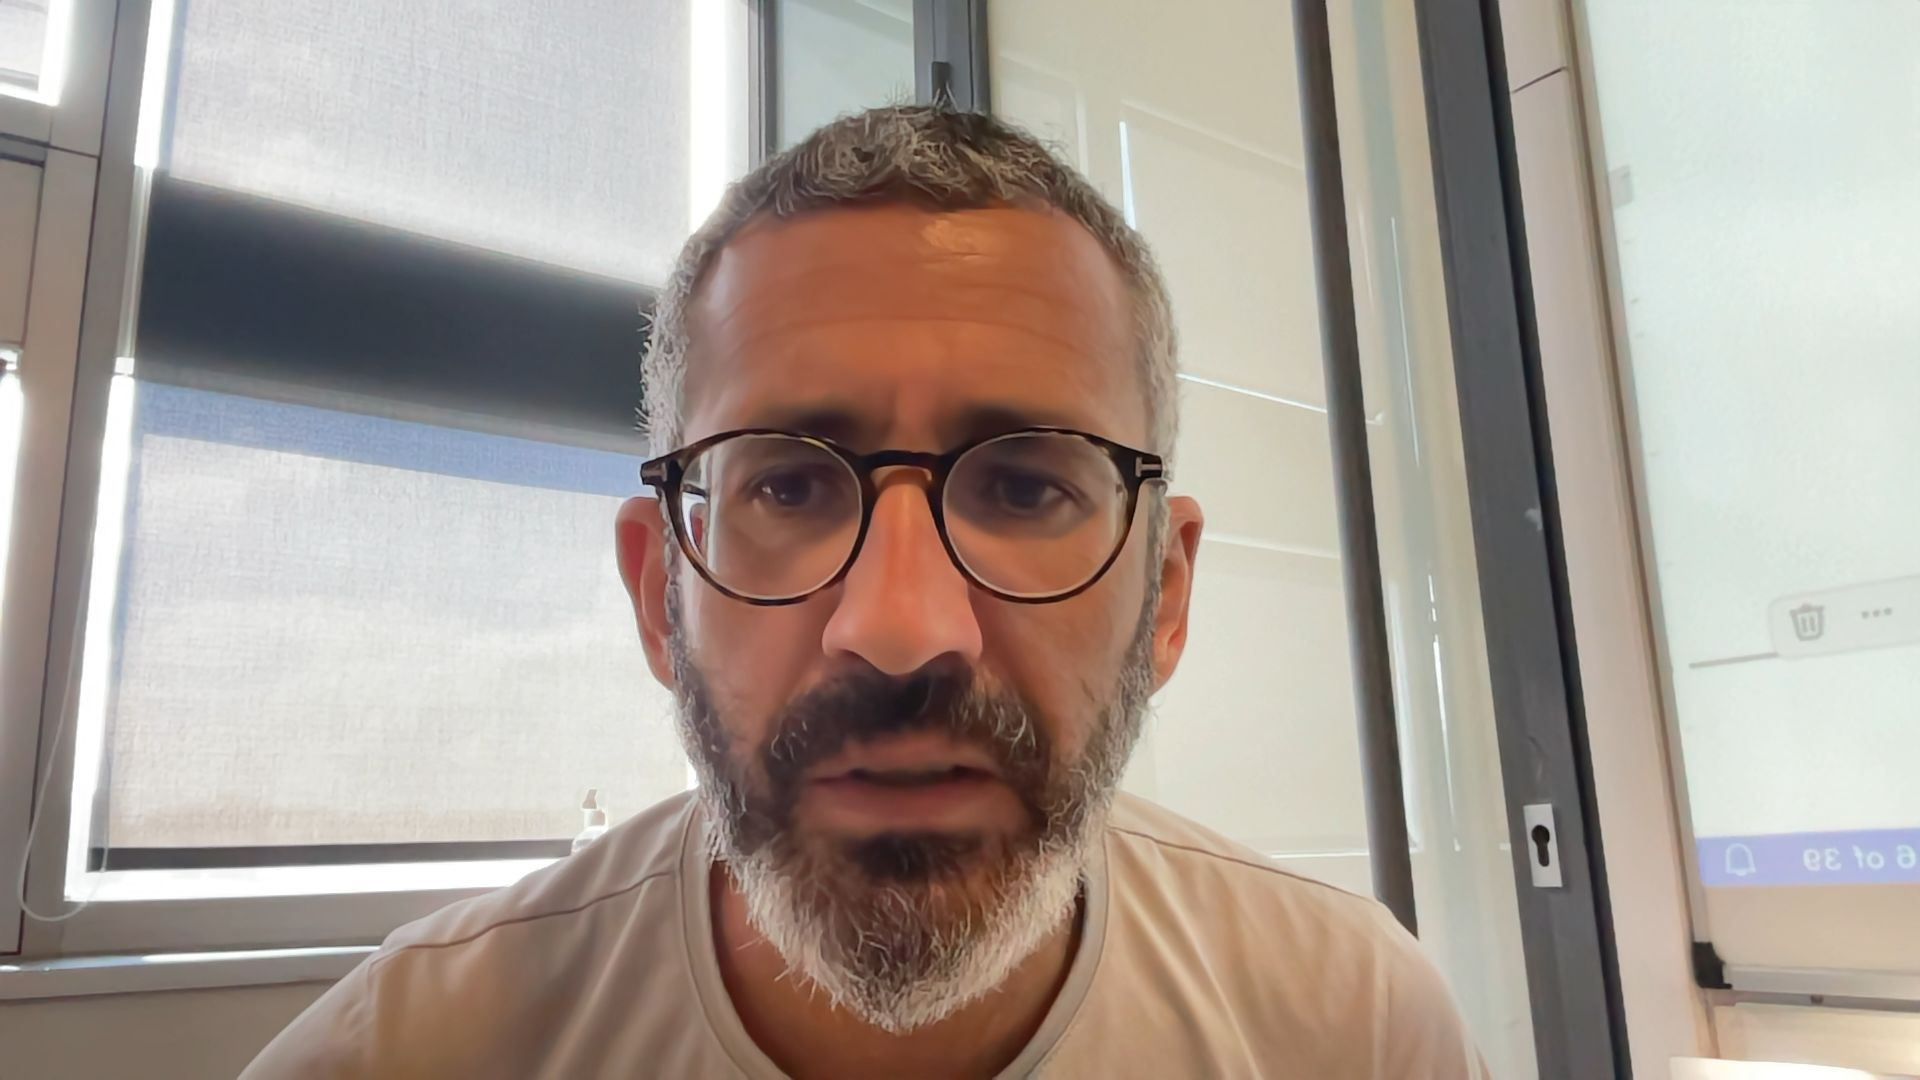

Détection seule       0 s restantes    (bouton ■ pour arrêter)


In [61]:
_ = live(annotate_detection_only, seconds=15, banner="Détection seule")

---
## 3. D'une image à un vecteur de nombres

Un classifieur ne sait pas manipuler une « image » : il manipule des **vecteurs**.
On transforme donc chaque visage détecté en une suite de nombres, toujours de la
même longueur :

1. on **découpe** la boîte du visage,
2. on passe en **niveaux de gris** (on jette la couleur : 3 fois moins de nombres),
3. on **redimensionne** en $32 \times 32$ — quel que soit l'éloignement du visage,
4. on divise par 255 pour ramener les valeurs entre 0 et 1,
5. on **aplatit** le tableau $32 \times 32$ en un vecteur de $32 \times 32 = 1024$ nombres.

$$\text{une image de visage} \;\longmapsto\; \vec{x} \in \mathbb{R}^{1024}$$

Chaque visage devient un **point** dans un espace à 1024 dimensions. Apprendre à
reconnaître un visage, c'est apprendre à séparer les points de cet espace en deux
groupes.

In [62]:
def face_vector(frame, box, size=IMG_SIZE):
    """Découpe le visage, normalise, et renvoie un vecteur de size*size nombres."""
    x, y, w, h = box
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    crop  = gray[y:y + h, x:x + w]
    small = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
    return small.astype(np.float32).ravel() / 255.0


def biggest_face(frame):
    """Renvoie la plus grande boîte détectée, ou None."""
    boxes = detect_faces(frame)
    if len(boxes) == 0:
        return None
    return max(boxes, key=lambda b: b[2] * b[3])

vecteur : (4096,) | min = 0.039 | max = 1.0


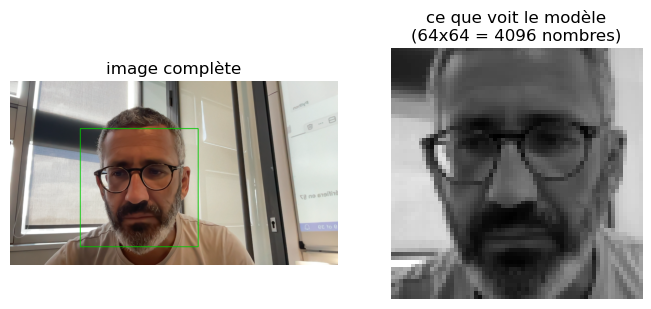

In [63]:
# Une image, une boîte, un vecteur : vérifions sur une capture unique.
cap = open_camera()
try:
    ok, frame = cap.read()
finally:
    cap.release()
frame = cv2.flip(frame, 1)

box = biggest_face(frame)
if box is None:
    print("Aucun visage détecté — placez-vous face à la caméra et relancez.")
else:
    v = face_vector(frame, box)
    print("vecteur :", v.shape, "| min =", v.min().round(3), "| max =", v.max().round(3))

    fig, ax = plt.subplots(1, 2, figsize=(7, 3.2))
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()
    x, y, w, h = box
    cv2.rectangle(rgb, (x, y), (x + w, y + h), (0, 200, 0), 3)
    ax[0].imshow(rgb);                       ax[0].set_title("image complète")
    ax[1].imshow(v.reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax[1].set_title(f"ce que voit le modèle\n({IMG_SIZE}x{IMG_SIZE} = {v.size} nombres)")
    for a in ax: a.axis("off")
    plt.tight_layout()

---
## 4. Constituer le jeu de données

On capture des exemples **étiquetés** : une série d'images pour chaque classe.

Conseils pour que ça marche :

- **bougez** un peu la tête pendant la capture (angles, distance, expression) ;
- capturez les deux classes dans **les mêmes conditions** (même lieu, même
  lumière) — sinon le modèle apprendra l'arrière-plan, on le vérifiera en §7 ;
- pour la classe « quelqu'un d'autre » : un collègue, ou à défaut une photo de
  visage affichée sur un téléphone face à la caméra.

In [64]:
def capture_class(n=40, countdown=3, width=520):
    """Capture n vecteurs de visage. Renvoie un tableau (n, IMG_SIZE**2)."""
    cap = open_camera()
    X = []
    try:
        t0 = time.time()
        while (dt := time.time() - t0) < countdown:          # décompte
            ok, frame = cap.read()
            if not ok:
                continue
            frame = cv2.flip(frame, 1)
            clear_output(wait=True)
            show_frame(frame, width)
            print(f"Préparez-vous...  {countdown - dt:.0f}")

        while len(X) < n:                                    # capture
            ok, frame = cap.read()
            if not ok:
                continue
            frame = cv2.flip(frame, 1)
            box = biggest_face(frame)
            if box is not None:
                X.append(face_vector(frame, box))
                draw_box(frame, box, f"{len(X)}/{n}", (0, 200, 0))
            clear_output(wait=True)
            show_frame(frame, width)
            print(f"{len(X)}/{n} images — bougez un peu la tête !")
    except KeyboardInterrupt:
        print("Interrompu.")
    finally:
        cap.release()
        clear_output(wait=True)
    print(f"{len(X)} images capturées.")
    return np.array(X, dtype=np.float32)

In [66]:
# --- Classe 0 : VOUS -----------------------------------------------------
X0 = capture_class(n=100)
print(X0.shape)

100 images capturées.
(100, 4096)


In [68]:
# --- Classe 1 : QUELQU'UN D'AUTRE ---------------------------------------
X1 = capture_class(n=100)
print(X1.shape)

100 images capturées.
(100, 4096)


In [69]:
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(len(X0), dtype=int), np.ones(len(X1), dtype=int)])

print("X :", X.shape, "  (une ligne = une image, une colonne = un pixel)")
print("y :", y.shape, "  valeurs :", np.unique(y))

np.savez("visages.npz", X=X, y=y)      # pour ré-entraîner sans tout recapturer
print("sauvegardé dans visages.npz")

X : (200, 4096)   (une ligne = une image, une colonne = un pixel)
y : (200,)   valeurs : [0 1]
sauvegardé dans visages.npz


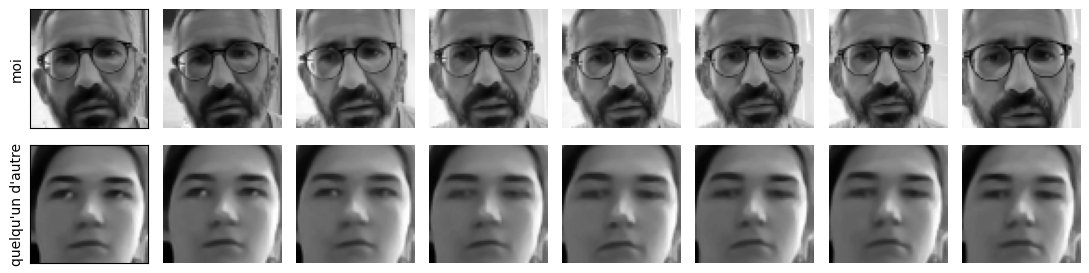

In [71]:
# Un aperçu des données : 8 exemples de chaque classe
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for k in (0, 1):
    idx = np.where(y == k)[0][:8]
    for j, i in enumerate(idx):
        axes[k, j].imshow(X[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[k, j].axis("off")
    axes[k, 0].set_ylabel(CLASSES[k])
    axes[k, 0].axis("on"); axes[k, 0].set_xticks([]); axes[k, 0].set_yticks([])
plt.tight_layout()

---
## 5. Entraîner le classifieur

On coupe le jeu de données en deux :

- le **train set** sert à apprendre,
- le **test set** est mis de côté et sert **uniquement** à mesurer.

Évaluer un modèle sur les données qui ont servi à l'entraîner n'a aucun sens :
c'est comme donner à l'examen les corrigés que l'on vient de distribuer.

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=0)

print("train :", X_train.shape, "   test :", X_test.shape)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

print(f"\nprécision train : {accuracy_score(y_train, model.predict(X_train)):.1%}")
print(f"précision test  : {accuracy_score(y_test,  model.predict(X_test)):.1%}")
print("\nmatrice de confusion (test) :\n", confusion_matrix(y_test, model.predict(X_test)))

train : (140, 4096)    test : (60, 4096)

précision train : 100.0%
précision test  : 100.0%

matrice de confusion (test) :
 [[30  0]
 [ 0 30]]


Le modèle a appris **un poids par pixel** : $1024$ nombres, à partir de
seulement $56$ images d'entraînement. Beaucoup plus de paramètres que d'exemples —
retenez ce déséquilibre, c'est la cause du sur-apprentissage.

On peut d'ailleurs *regarder* ce qu'il a appris, en réaffichant le vecteur de
poids sous forme d'image $32 \times 32$ : rouge = pixel qui pousse vers « moi »,
bleu = pixel qui pousse vers « l'autre ».

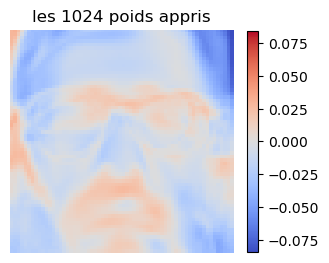

In [73]:
w = model.coef_.reshape(IMG_SIZE, IMG_SIZE)
lim = np.abs(w).max()

plt.figure(figsize=(3.6, 3.6))
plt.imshow(w, cmap="coolwarm", vmin=-lim, vmax=lim)
plt.colorbar(shrink=0.8)
plt.title("les 1024 poids appris")
plt.axis("off");

---
## 6. La reconnaissance en direct

Rien de nouveau : pour chaque visage détecté, on calcule son vecteur, on demande
sa classe au modèle, et on dessine le cadre de la bonne couleur.

In [74]:
def annotate_prediction(frame):
    for box in detect_faces(frame):
        v = face_vector(frame, box).reshape(1, -1)   # sklearn attend une matrice
        proba = model.predict_proba(v)[0]
        k = int(model.classes_[np.argmax(proba)])
        draw_box(frame, box, f"{CLASSES[k]}  {proba.max():.0%}", COLORS[k])

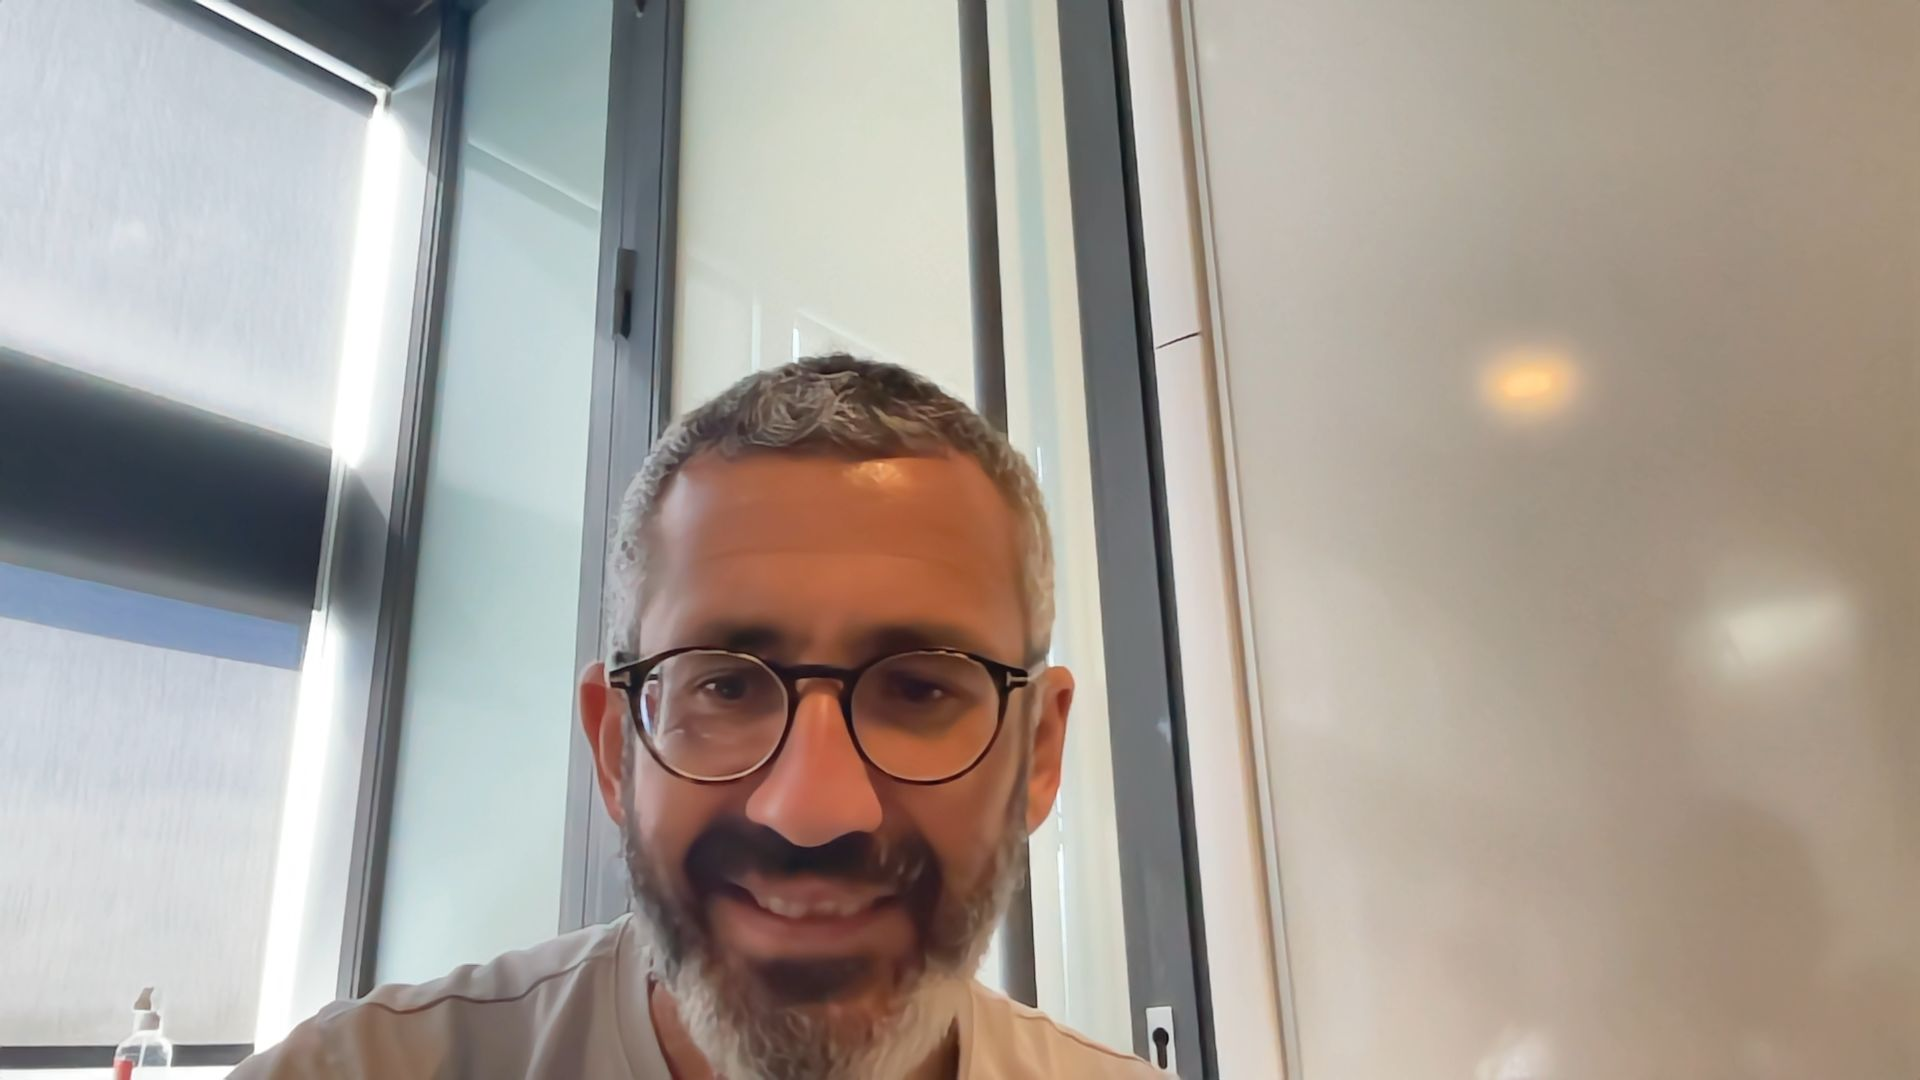

Reconnaissance       0 s restantes    (bouton ■ pour arrêter)


In [75]:
_ = live(annotate_prediction, seconds=30, banner="Reconnaissance")

---
## 7. Casser le modèle (le cœur du TP)

Le score en test est flatteur. Mais train et test viennent de **la même séance de
capture** : même lumière, même arrière-plan, même chemise. Rien ne prouve que le
modèle a appris *votre visage* plutôt que *votre décor*.

Le seul test honnête : capturer un **nouveau** jeu de données, dans des conditions
différentes.

### Expérience 1 — changer de décor

Déplacez-vous (autre pièce, ou tournez-vous de 90°), puis lancez la cellule
ci-dessous pour capturer un nouveau jeu de test.

In [23]:
X0_new = capture_class(n=20)     # vous, ailleurs
X1_new = capture_class(n=20)     # l'autre personne, ailleurs

X_new = np.vstack([X0_new, X1_new])
y_new = np.hstack([np.zeros(len(X0_new), int), np.ones(len(X1_new), int)])

print(f"précision sur le test initial      : {accuracy_score(y_test, model.predict(X_test)):.1%}")
print(f"précision dans de nouvelles conditions : {accuracy_score(y_new, model.predict(X_new)):.1%}")

20 images capturées.
précision sur le test initial      : 100.0%
précision dans de nouvelles conditions : 47.5%


**Questions**

1. L'écart entre les deux scores : d'où vient-il ? Qu'a réellement appris le modèle ?
2. Le modèle a $1024$ poids et $56$ exemples d'entraînement. Que se passe-t-il si
   vous relancez tout avec `IMG_SIZE = 8` (donc 64 poids seulement) ? Le score en
   train baisse-t-il ? Et en test ?
3. Ajoutez les nouvelles images au jeu d'entraînement et ré-entraînez. Le modèle
   devient-il plus robuste ? Pourquoi ?
4. Que se passe-t-il si vous capturez la classe 0 devant la fenêtre et la classe 1
   devant le mur ? Le score en test est excellent — le modèle est-il bon ?
5. Le détecteur de visages, lui, n'a jamais été ré-entraîné et fonctionne partout.
   Quelle différence avec votre classifieur ?

### Expérience 2 — l'anti-sèche

Pour rendre le problème visible, entraînez volontairement un modèle « tricheur » :
capturez la classe 0 assis, et la classe 1 debout. Le modèle atteindra 100 % en
test tout en étant parfaitement inutile.

In [24]:
# Ré-entraînement sur l'ensemble des données disponibles (initiales + nouvelles)
X_all = np.vstack([X, X_new])
y_all = np.hstack([y, y_new])

Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.30,
                                      stratify=y_all, random_state=0)
model = LogisticRegression(max_iter=5000).fit(Xtr, ytr)

print(f"train : {accuracy_score(ytr, model.predict(Xtr)):.1%}")
print(f"test  : {accuracy_score(yte, model.predict(Xte)):.1%}")

train : 100.0%
test  : 100.0%


---
## 8. Nettoyage

À exécuter en fin de séance : les images capturées sont des données personnelles.

In [25]:
import os
for f in ["visages.npz"]:
    if os.path.exists(f):
        os.remove(f)
        print("supprimé :", f)

for name in ["X", "X0", "X1", "X_new", "X0_new", "X1_new", "X_all",
             "X_train", "X_test", "Xtr", "Xte", "frame"]:
    globals().pop(name, None)
print("données effacées de la mémoire.")

supprimé : visages.npz
données effacées de la mémoire.


---
### Ce qu'il faut retenir

- Un système de ML, c'est **des données étiquetées + un modèle + une mesure**.
- Une image devient un **vecteur** ; apprendre, c'est séparer des points.
- Un score élevé **sur les données d'entraînement ne prouve rien**.
- Un score élevé sur un test issu de la même séance de capture ne prouve pas
  grand-chose non plus : c'est le **changement de conditions** qui teste
  vraiment la généralisation.
- Plus le modèle a de paramètres par rapport au nombre d'exemples, plus il
  apprend des détails inutiles — c'est le **sur-apprentissage**.